# HW 5.1 - Illinois Building Inventory: Altair Visualizations

This notebook explores the Illinois Building Inventory dataset, which contains records of government-owned buildings across the state of Illinois. The dataset includes information about each building's agency, square footage, year of construction, usage type, building status, and congressional district representation.

I will create two visualizations using Altair and Vega-Lite:
1. **Visualization 1 (Interactive):** A horizontal bar chart showing total square footage by agency, with a dropdown selector to filter by building usage type.
2. **Visualization 2:** A heatmap showing building count by county and usage type across the top 15 counties.

# Loading the Dataset

We begin by importing the necessary libraries and reading the building inventory dataset directly from the course GitHub repository URL. I am treating zero values in `Year Acquired`, `Year Constructed`, and `Square Footage` as missing since a value of zero for these columns is not physically meaningful, example, a building cannot have been constructed in year 0 or have zero square footage.

In [1]:
import pandas as pd
import altair as alt

alt.data_transformers.disable_max_rows()
alt.renderers.enable('png')

url = "https://raw.githubusercontent.com/UIUC-iSchool-DataViz/is445_data/main/building_inventory.csv"
buildings = pd.read_csv(url, na_values={"Year Acquired": 0, "Year Constructed": 0, "Square Footage": 0})

print("Dataset Shape:", buildings.shape)
buildings.head()


Dataset Shape: (8862, 22)


,Agency Name,Location Name,Address,City,Zip code,County,Congress Dist,Congressional Full Name,Rep Dist,Rep Full Name,...,Bldg Status,Year Acquired,Year Constructed,Square Footage,Total Floors,Floors Above Grade,Floors Below Grade,Usage Description,Usage Description 2,Usage Description 3
0,Department of Natural Resources,Anderson Lake Conservation Area - Fulton County,Anderson Lake C.a.,Astoria,61501,Fulton,17,Cheri Bustos,93,Hammond Norine K.,...,In Use,1975.0,1975.0,144.0,1,1,0,Unusual,Unusual,Not provided
1,Department of Natural Resources,Anderson Lake Conservation Area - Fulton County,Anderson Lake C.a.,Astoria,61501,Fulton,17,Cheri Bustos,93,Hammond Norine K.,...,In Use,2004.0,2004.0,144.0,1,1,0,Unusual,Unusual,Not provided
2,Department of Natural Resources,Anderson Lake Conservation Area - Fulton County,Anderson Lake C.a.,Astoria,61501,Fulton,17,Cheri Bustos,93,Hammond Norine K.,...,In Use,2004.0,2004.0,144.0,1,1,0,Unusual,Unusual,Not provided
3,Department of Natural Resources,Anderson Lake Conservation Area - Fulton County,Anderson Lake C.a.,Astoria,61501,Fulton,17,Cheri Bustos,93,Hammond Norine K.,...,In Use,2004.0,2004.0,144.0,1,1,0,Unusual,Unusual,Not provided
4,Department of Natural Resources,Anderson Lake Conservation Area - Fulton County,Anderson Lake C.a.,Astoria,61501,Fulton,17,Cheri Bustos,93,Hammond Norine K.,...,In Use,2004.0,2004.0,144.0,1,1,0,Unusual,Unusual,Not provided


# Initial Data Exploration

Before building visualizations, I want to understand the distribution of key columns, specifically how many unique agencies exist, what usage types are present, and what the building status categories look like. This will inform which columns make for effective visual encodings.

In [2]:
print("=== Agency Name ===")
print(f"Unique agencies: {buildings['Agency Name'].nunique()}")
print(buildings['Agency Name'].value_counts().head(10))
print()

print("=== Usage Description ===")
print(f"Unique usage types: {buildings['Usage Description'].nunique()}")
print(buildings['Usage Description'].value_counts())
print()

print("=== Building Status ===")
print(buildings['Bldg Status'].value_counts())


=== Agency Name ===
Unique agencies: 35
Agency Name
Department of Natural Resources    3223
Department of Corrections          1428
Department of Transportation       1137
Department of Human Services        617
University of Illinois              525
Southern Illinois University        420
Historic Preservation Agency        284
Department of Military Affairs      231
Department of Agriculture           228
Department of Juvenile Justice      120
Name: count, dtype: int64

=== Usage Description ===
Unique usage types: 13
Usage Description
Storage                 2231
Unusual                 1684
Industrial              1174
Assembly                 948
Detention & Correc       731
Business                 715
Residential              636
Health Care              382
Education                258
Mercantile                77
Utiility & Miscellan      21
Not provided               4
Public                     1
Name: count, dtype: int64

=== Building Status ===
Bldg Status
In Use        

# Data Transformation - Visualization 1

For the first visualization, I want to show total square footage controlled by each state agency. Since there are 35 unique agencies, displaying all of them would make the chart cluttered and hard to read. I am filtering to the top 10 agencies by total square footage. I am also dropping rows where Square Footage is missing since those records would not contribute meaningful information to the aggregation.

In [3]:
buildings_clean = buildings.dropna(subset=["Square Footage"]).copy()

top_agencies = (
    buildings_clean.groupby("Agency Name")["Square Footage"]
    .sum()
    .nlargest(10)
    .index
    .tolist()
)

buildings_top = buildings_clean[buildings_clean["Agency Name"].isin(top_agencies)].copy()
buildings_top["Square Footage (Millions)"] = buildings_top["Square Footage"] / 1_000_000

print(f"Filtered dataset: {buildings_top.shape[0]} buildings across top 10 agencies")
print("Top 10 agencies by total sqft:", top_agencies)


Filtered dataset: 7770 buildings across top 10 agencies
Top 10 agencies by total sqft: ['University of Illinois', 'Department of Corrections', 'Southern Illinois University', 'Department of Human Services', 'Department of Transportation', 'Department of Military Affairs', 'Department of Central Management Services', 'Department of Natural Resources', 'Northern Illinois University', 'Illinois State University']


# Visualization 1 - Total Square Footage by Agency (Interactive)

This horizontal bar chart shows the total square footage managed by the top 10 Illinois state agencies. The interactivity comes from a **dropdown selector** that lets the viewer filter the data by building usage type (e.g., Education, Storage, Health Care). This goes beyond simple pan/zoom - it allows the viewer to compare how different agencies allocate space across different usage categories, revealing patterns that a static chart would obscure.

For example, selecting "Education" immediately reveals that universities dominate the square footage, while selecting "Detention & Correc" shows the Department of Corrections leading by a wide margin. This kind of filtering interaction makes the visualization much more informative than a single static aggregation.

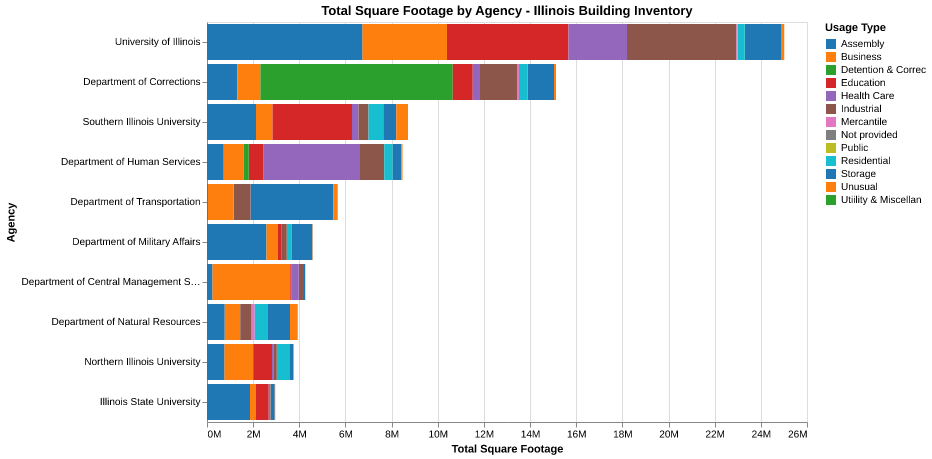

In [4]:
usage_options = sorted(buildings_top["Usage Description"].unique().tolist())

usage_dropdown = alt.binding_select(options=[None] + usage_options, labels=["All Usage Types"] + usage_options, name="Usage Type: ")
usage_selection = alt.selection_point(fields=["Usage Description"], bind=usage_dropdown)

chart1 = (
    alt.Chart(buildings_top)
    .mark_bar()
    .encode(
        x=alt.X("sum(Square Footage):Q", title="Total Square Footage", axis=alt.Axis(format="~s")),
        y=alt.Y("Agency Name:N", sort="-x", title="Agency"),
        color=alt.Color("Usage Description:N", scale=alt.Scale(scheme="category10"), title="Usage Type"),
        tooltip=[
            alt.Tooltip("Agency Name:N", title="Agency"),
            alt.Tooltip("sum(Square Footage):Q", title="Total Sq Ft", format=",.0f"),
            alt.Tooltip("Usage Description:N", title="Usage Type"),
        ],
    )
    .add_params(usage_selection)
    .transform_filter(usage_selection)
    .properties(width=600, height=400, title="Total Square Footage by Agency - Illinois Building Inventory")
)

chart1


# Data Transformation - Visualization 2

For the second visualization, I want to explore how building usage varies across different counties in Illinois. Since there are 102 unique counties in the dataset, displaying all of them would make the chart unreadable. I am filtering to the top 15 counties by total building count. I am also computing the count of buildings for each county and usage type combination to populate the heatmap cells.

In [5]:
top_counties = (
    buildings.groupby('County')
    .size()
    .nlargest(15)
    .index
    .tolist()
)

buildings_heatmap = buildings[buildings['County'].isin(top_counties)].copy()

print(f'Heatmap dataset: {buildings_heatmap.shape[0]} buildings across top 15 counties')
print('Top 15 counties:', top_counties)

Heatmap dataset: 4322 buildings across top 15 counties
Top 15 counties: ['Cook', 'Jackson', 'Randolph', 'Sangamon', 'Champaign', 'Will', 'LaSalle', 'Jersey', 'McLean', 'Peoria', 'Madison', 'Jefferson', 'Kankakee', 'Lee', 'Livingston']


# Visualization 2 - Building Count by County and Usage Type

This heatmap shows the distribution of government buildings across the top 15 Illinois counties, broken down by usage type. Each cell in the grid represents the count of buildings for a given county-usage combination. The color intensity encodes the count as a quantitative variable, with darker cells indicating a higher concentration of buildings. I chose the Greens sequential color scheme because it naturally conveys magnitude from low (light) to high (dark) and is intuitive for count data where we want to quickly spot the densest concentrations.

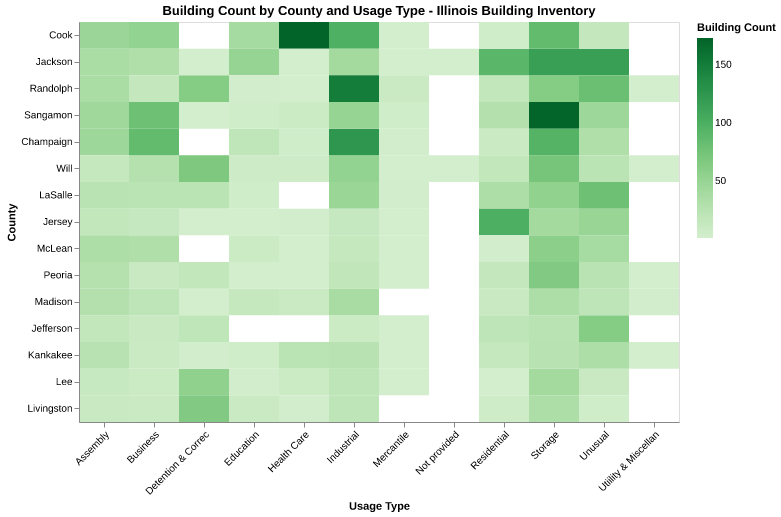

In [6]:
chart2 = (
    alt.Chart(buildings_heatmap)
    .mark_rect()
    .encode(
        x=alt.X('Usage Description:N', title='Usage Type', axis=alt.Axis(labelAngle=-45)),
        y=alt.Y('County:N', title='County', sort=alt.EncodingSortField(op='count', order='descending')),
        color=alt.Color('count():Q', scale=alt.Scale(scheme='greens'), title='Building Count'),
        tooltip=[
            alt.Tooltip('County:N', title='County'),
            alt.Tooltip('Usage Description:N', title='Usage Type'),
            alt.Tooltip('count():Q', title='Count'),
        ],
    )
    .properties(width=600, height=400, title='Building Count by County and Usage Type - Illinois Building Inventory')
)

chart2

# Exporting the Visualizations

Finally, I am saving both charts as JSON files so they can be embedded in the Jekyll webpage using vega-embed. This is the standard approach for getting Altair charts to render on a static GitHub Pages site.

In [7]:
chart1.save("chart1.json")
chart2.save("chart2.json")

print("Charts saved as chart1.json and chart2.json")


Charts saved as chart1.json and chart2.json
